# Plasmadiagnostik mit Langmuir-Sonden

In [8]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.optimize import least_squares
import os

In [24]:
def linear_res(coeff, x, y):
    a, b = coeff
    return y - (a*x+b)

def linear(coeff, x):
    a, b = coeff
    return a*x+b

def derive(x, y, step=1):
    x, y = list(x), list(y)
    x_new, y_new, x_shifted = [], [], []
    for i, val in enumerate(x):
        if i%step == 0:
            x_new.append(val)
    for i, val in enumerate(y):
        if i % step == 0:
            y_new.append(val)
    x_new = np.array(x_new)
    y_new = np.array(y_new)
    der = np.insert(np.diff(y_new)/np.diff(x_new), 0, np.nan)
    for i in range(len((x_new))):
        x_shifted.append(x_new[i] - (abs(x_new[i]-x_new[i-1])/2))
    return x_shifted, der

## Bestimmen des Plasmapotentials für alle (Sonden-) Kennlinien

Mögliche Methoden zur Bestimmung:
 1. Wendepunkt der Kennlinie: Maximum von $\frac{\mathrm{d}I_e(U)}{\mathrm{d}U}$
 2. Schnittpunkt der Geraden im $\ln (I_e)$ gegen $U$ plot

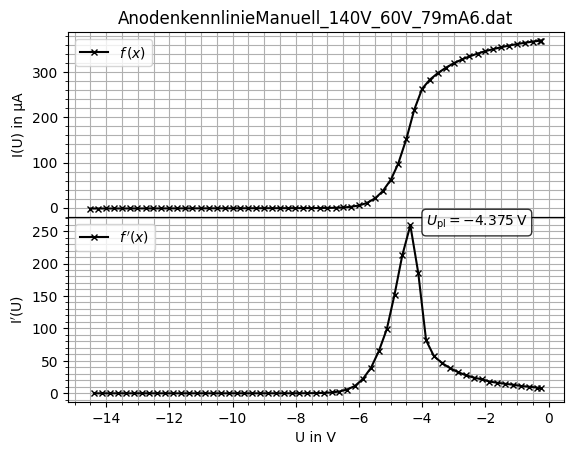

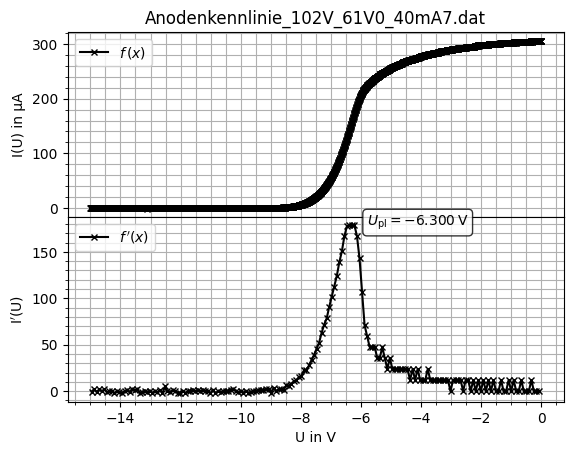

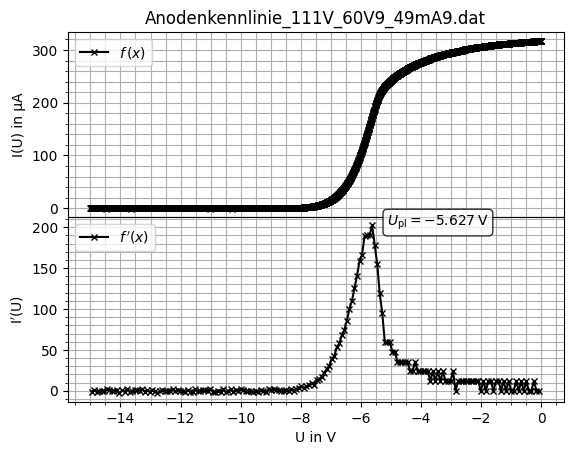

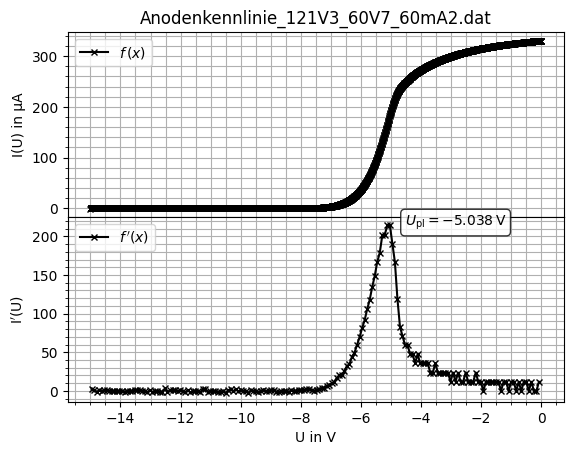

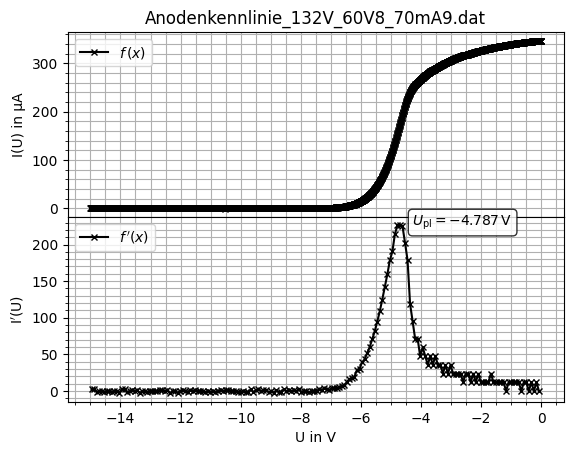

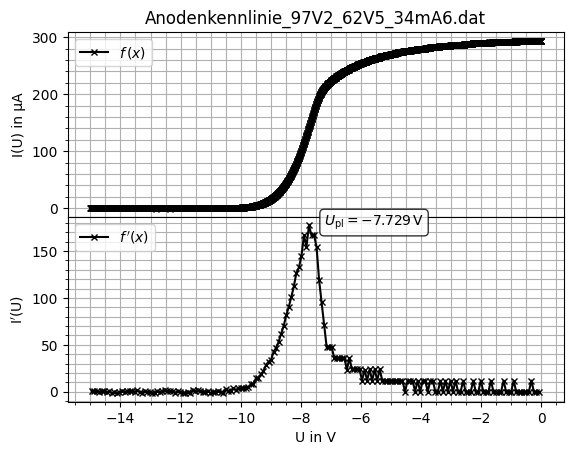

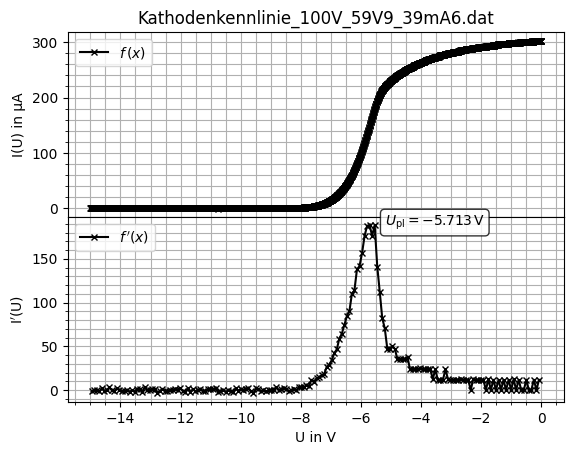

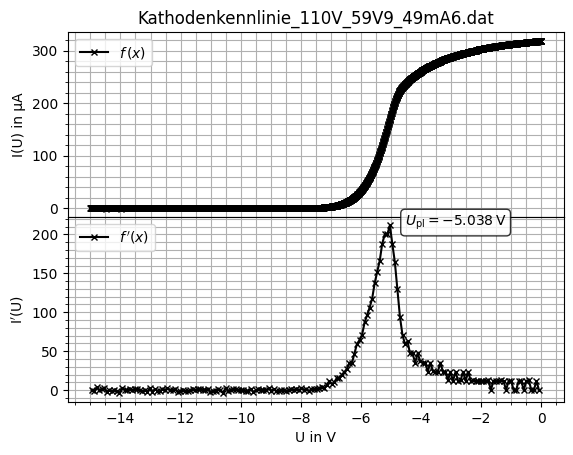

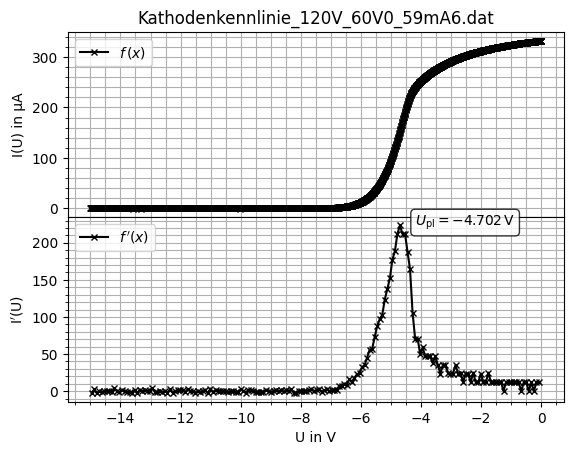

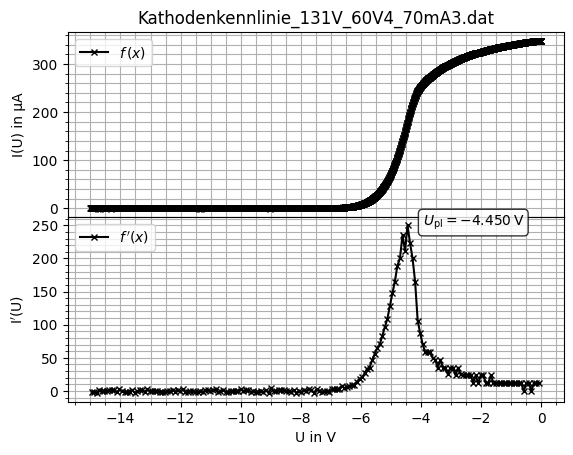

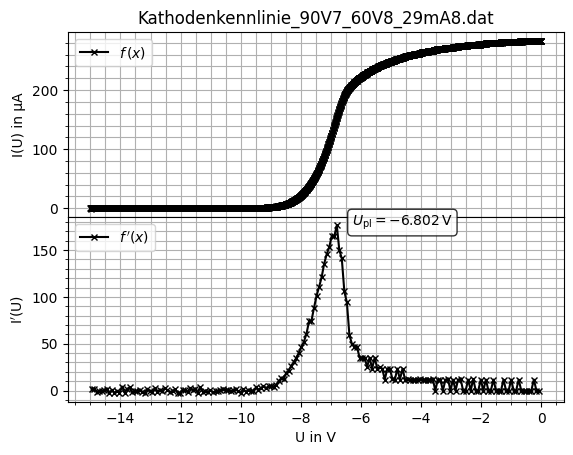

In [27]:
# Methode 1

for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Ableiten der Kennlinie funktioniert für die automatischen nur mit größeren Steigungsdreiecken
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            dU, dIdU = derive(U, I, step=1)
        else:
            dU, dIdU = derive(U, I, step=14)
        imaxI = np.argmax(dIdU[1:])+1
        Upl = dU[imaxI]
        # plotten
        fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, gridspec_kw={'hspace':0.0}) #layout='constrained')
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax2.plot(dU, dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
        ax2.set_xlabel('U in V')
        ax2.set_ylabel(r"I$'$(U)")
        ax1.set_ylabel('I(U) in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax2.legend(loc=2)
        ax2.grid(which='both')
        ax1.minorticks_on()
        ax2.minorticks_on()
        ax2.text(Upl+0.5, dIdU[imaxI], r'$U_\mathrm{pl}= %4.3f \,$V' %Upl, fontsize=10, bbox={'boxstyle':'round', 'alpha':0.8, 'fc':'white', 'ec':'black'})
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
        plt.show()

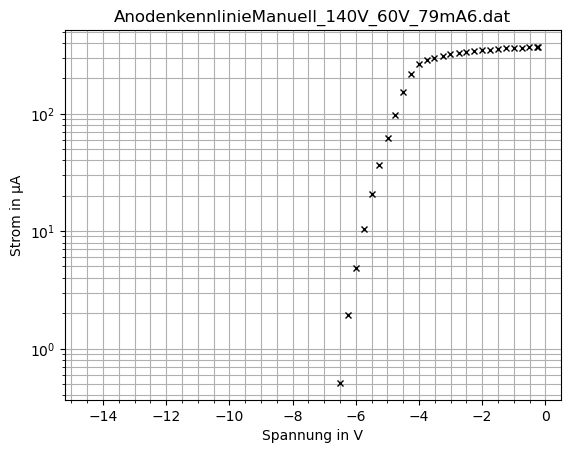

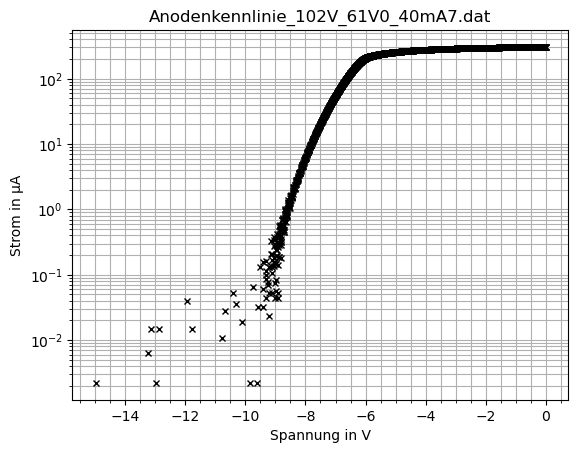

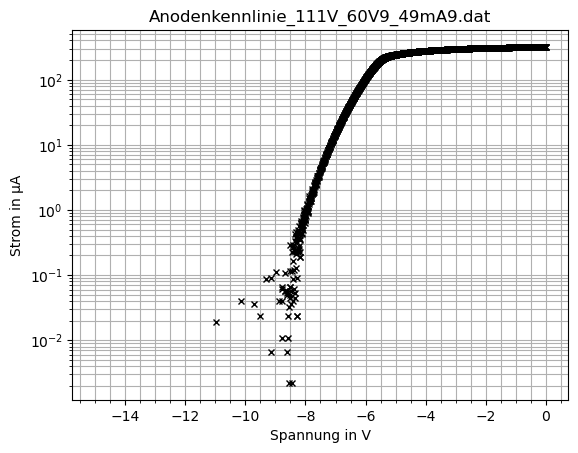

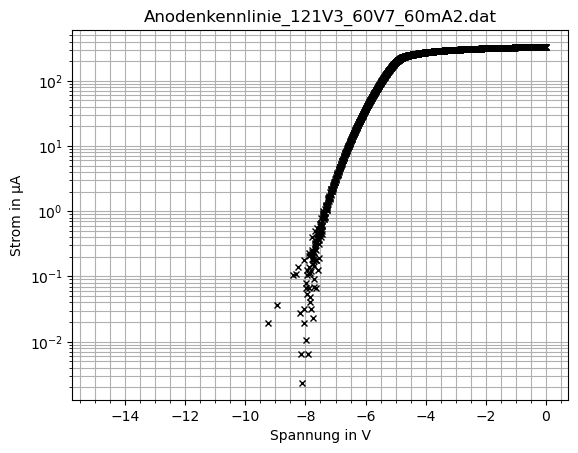

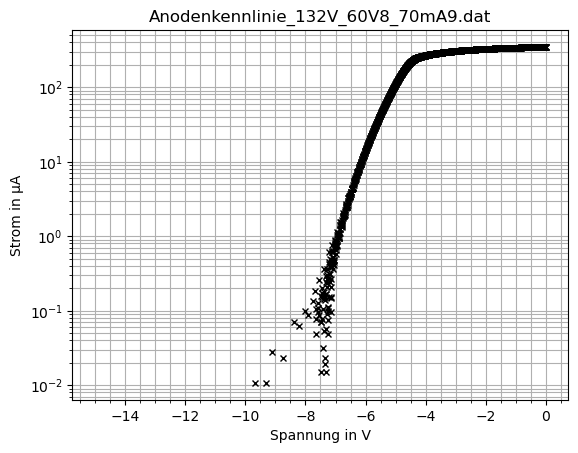

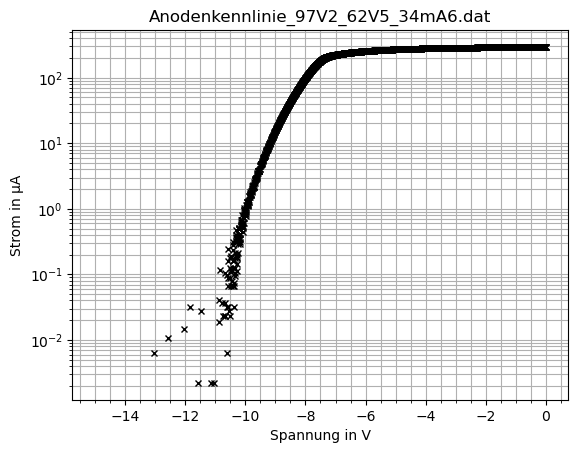

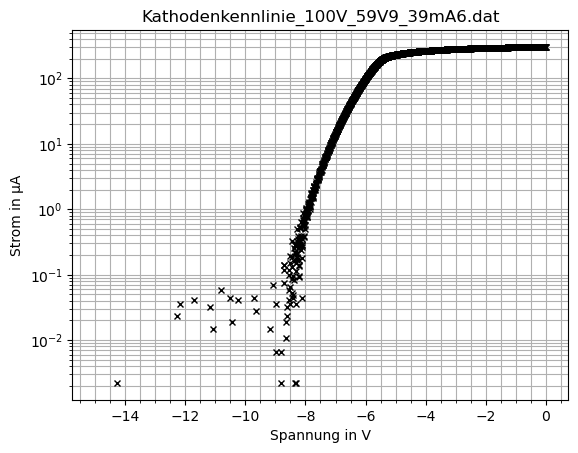

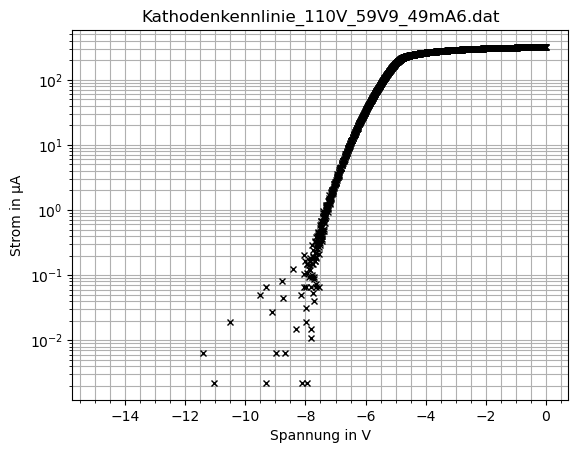

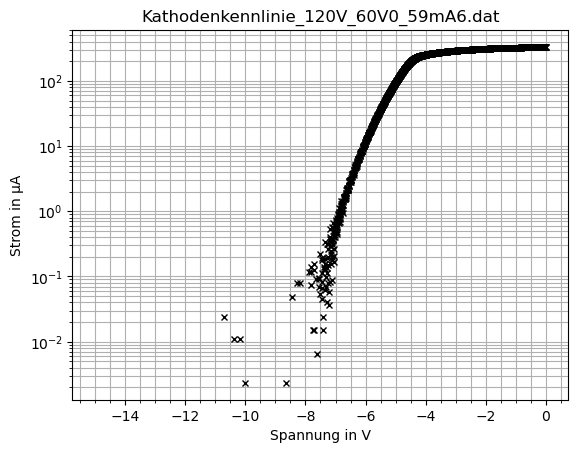

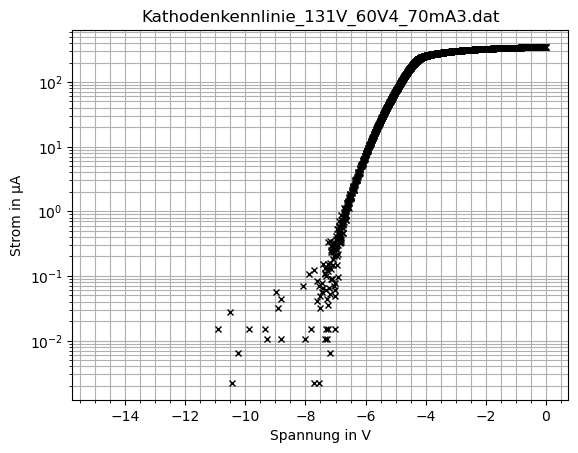

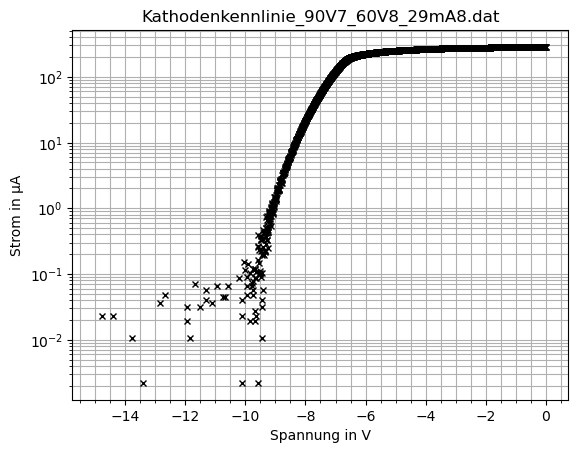

In [4]:
# Methode 2


for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax = plt.subplots()
        ax.plot(U, I, 'xk', ms=4)
        ax.set_xlabel('Spannung in V')
        ax.set_ylabel('Strom in µA')
        ax.set_title(file)
        ax.set_yscale('log')
        ax.minorticks_on()
        plt.grid(which = 'both')
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_logplot.png')
        plt.show()

## Bestimmen des Floating-Potential und Elektronentemperatur
Floating-Potential ist der Nulldurchgang $I(U_\mathrm{float})=0$.  
Für den Elektronstrom im Elektronenanlaufbereich gilt: $$I_\mathrm{e}(U)=-\frac{1}{4}en_eA\sqrt{\frac{8k_BT_e}{\pi m_e}}\exp\left(\frac{e(U-U_{pl})}{k_BT_e} \right).$$

Dies lässt sich umformen zu $$\ln\left(\frac{I_e(U)}{1\,mA}\right)\propto\frac{eU}{k_BT_e}.$$
Aus der Steigung im halblogarithmisch geplotteten Elektronenanlaufbereich lässt sich also die Elektronentemperatur bestimmen. Dies sei Methode 1.

Methode 2 ist eine weitere Gleichung $$k_BT_e=\frac{e}{\ln\sqrt{\frac{\exp 1}{2\pi}\frac{m_i}{m_e}}}(U_{pl}-U_{float}).$$

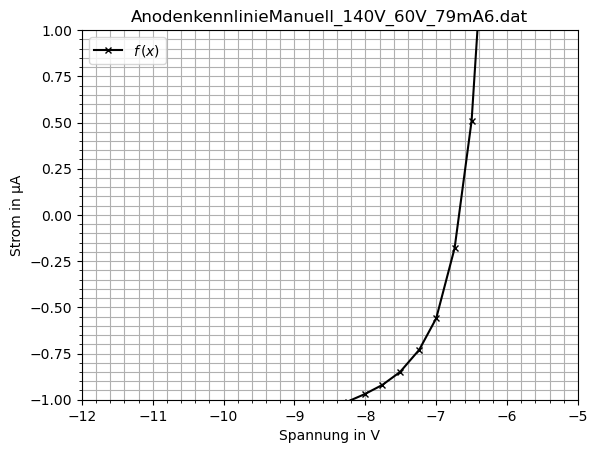

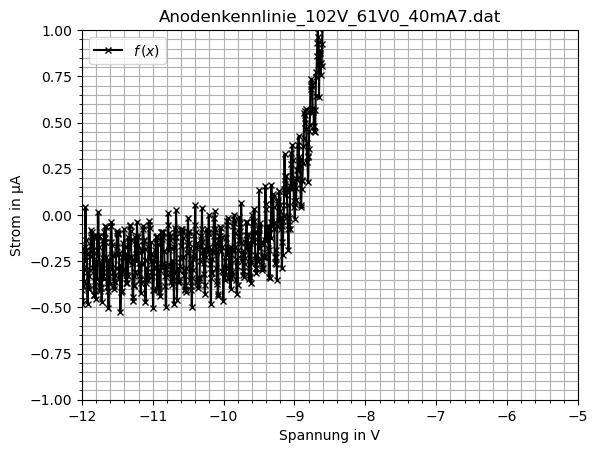

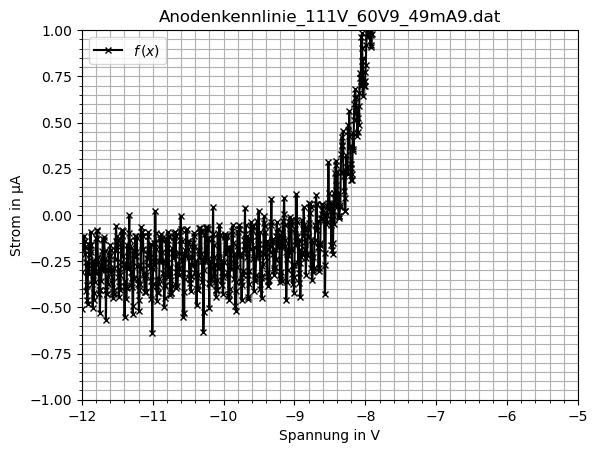

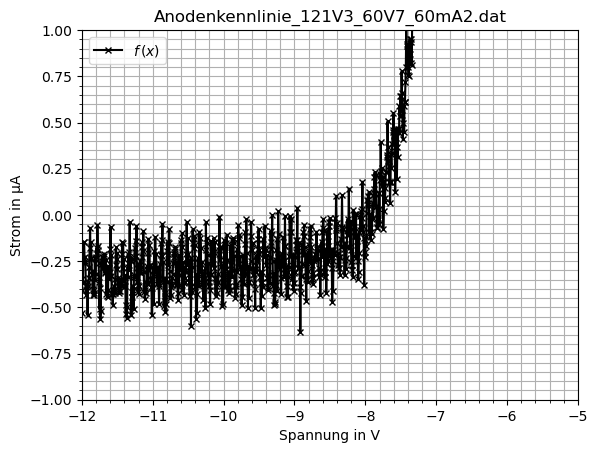

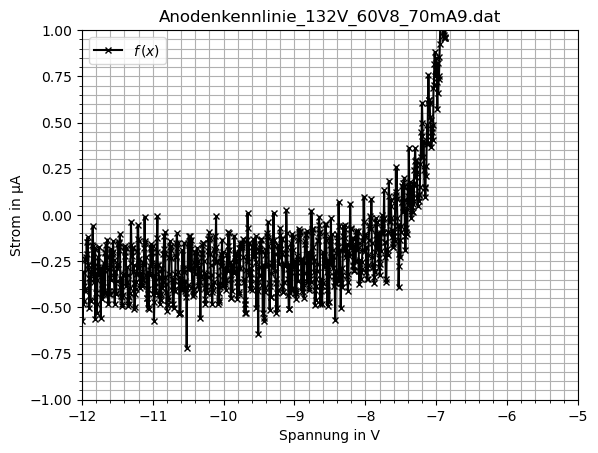

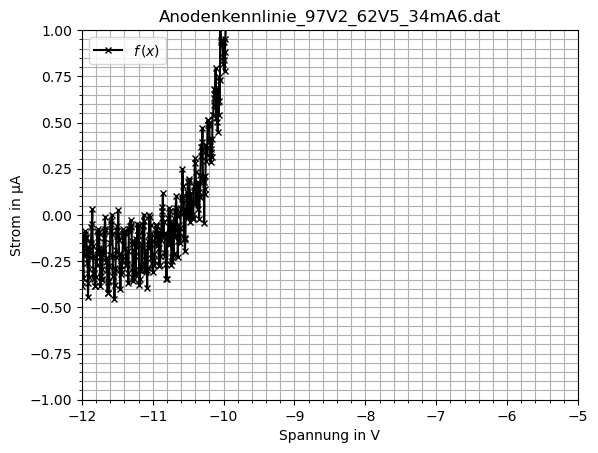

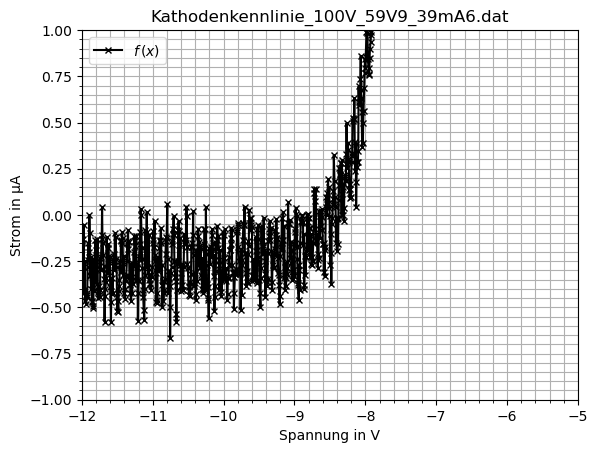

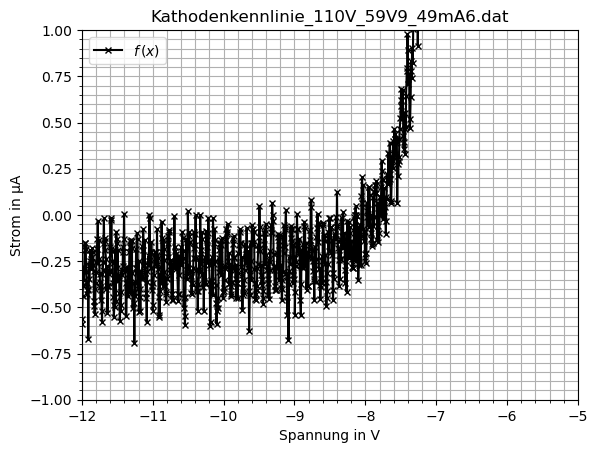

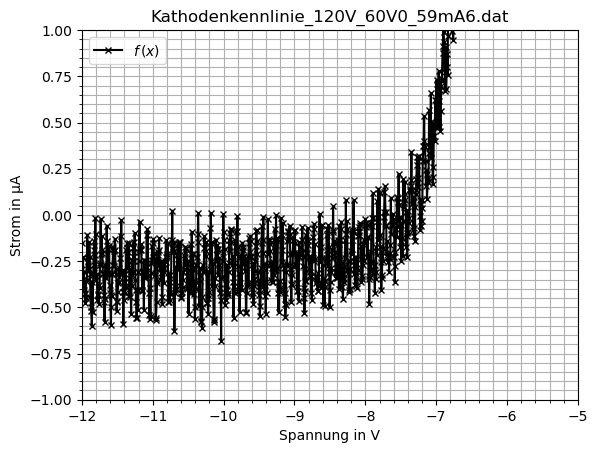

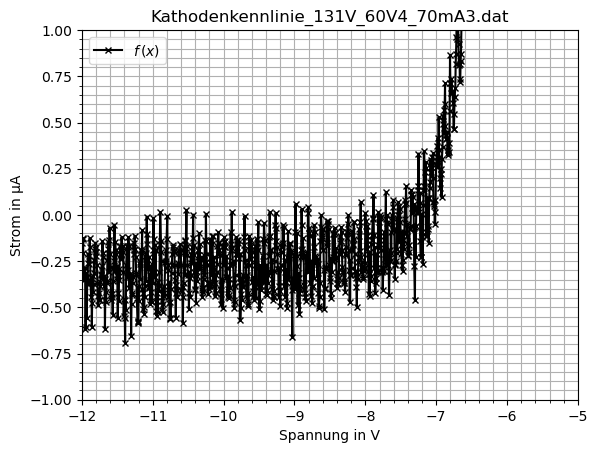

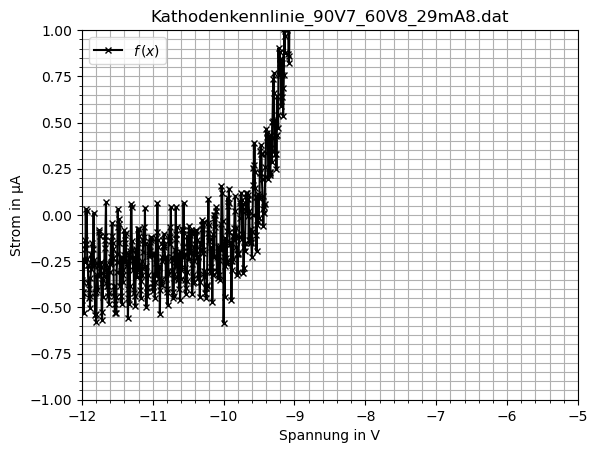

In [ ]:
# gezoomte lnI U plots
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax1 = plt.subplots()
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax1.set_xlabel('Spannung in V')
        ax1.set_ylabel('Strom in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax1.minorticks_on()
        ax1.set_ylim(-1, 1) # reinzoomen um Nulldurchgang abzulesen
        ax1.set_xlim(-12,-5)
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_zoom_Nulldurchgang.png')
        plt.show()

In [6]:
# Nulldurchgang dict
Ufl = {'140V' : -6.7, # manuelle Kennlinie
       '102V' : -9.2, # Anodenkennlinien
       '111V' : -9.5,
       '121V3': -7.8,
       '132V' : -7.5,
       '97V2' : -10.5,
       '90V7' : -9.6, # Kathodenkennlinien
       '100V' : -8.5,
       '110V' : -7.9,
       '120V' : -7.5,
       '131V' : -7.4
      } # in V

In [7]:
# Methode 1 Steigungsdreieck in halblog plot ablesen
Steigung = {'140V' : 264.66666667, # manuelle Kennlinie
            '102V' : 79.984, # Anodenkennlinien
            '111V' : 91.92,
            '121V3': 199.75,
            '132V' : 164.7,
            '97V2' : 114.27428571,
            '90V7' : 64.425, # Kathodenkennlinien
            '100V' : 119.92,
            '110V' : 124.75,
            '120V' : 74.875,
            '131V' : 99.85
            } # in µA/V

Te = const.e/np.array(list(Steigung.values()), dtype=float)/const.k
print(f'Elektronentemperatur: {Te.mean()} K')

Elektronentemperatur: 107.85461333136658 K


In [ ]:
# Methode 1 linear Fit im halb-ln plot
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Upl als obere Grenze für Fit bestimmen
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            dU = U
            dIdU = np.insert(np.diff(I)/np.diff(U), 0, np.nan)
        else:
            dU, dIdU = derive(U, I, step=14)
        imaxI = np.argmax(dIdU[1:])+1
        Upl = dU[imaxI]
        # plotten
        fig, ax1 = plt.subplots()
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax1.set_xlabel('Spannung in V')
        ax1.set_ylabel('Strom in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax1.minorticks_on()
        ax1.set_ylim(-1, 1) # reinzoomen um Nulldurchgang abzulesen
        ax1.set_xlim(-12,-5)
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_zoom_Nulldurchgang.png')
        plt.show()

## Druyvesteyn Methode

zweite Ableitung der manuellen Kennlinie zur Berechnung der Geschwindigkeitsverteilung

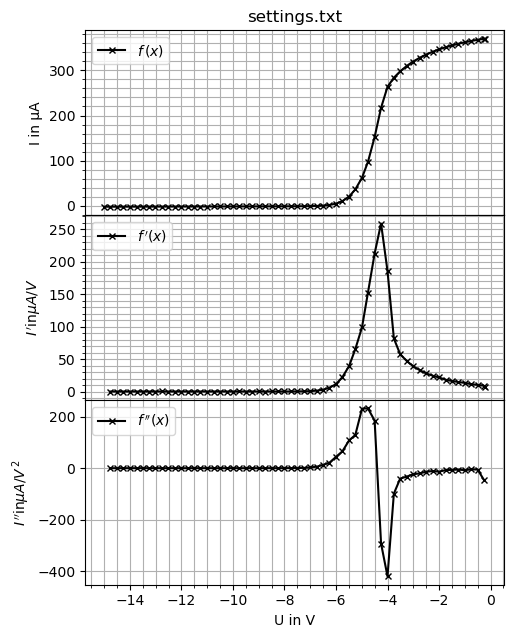

In [ ]:
manlinie = np.loadtxt('../Messdaten/17112025_Langmuirsonden/AnodenkennlinieManuell_140V_60V_79mA6.dat', delimiter='\t', skiprows=1)

U = manlinie[:,0]
I = manlinie[:,1]*1e6 #in µA

dIdU = np.diff(I)/np.diff(U)
d2IdU2 = np.diff(dIdU)/np.diff(U[1:])


# plotten
fig, (ax1, ax2, ax3) = plt.subplots(3,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,7.2)) #layout='constrained')
ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
ax2.plot(U[1:], dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
ax3.plot(U[1:-1], d2IdU2, 'x-k', ms=4, label=r"$f\,^{\prime\prime} (x)$")
ax3.set_xlabel('U in V')
ax1.set_ylabel('I in µA')
ax2.set_ylabel(r'$I\,^\prime \mathrm{ in } µA/V$')
ax3.set_ylabel(r'$I\,^{\prime\prime} \mathrm{ in } µA/V\,^2$')
ax1.set_title(file)
ax1.legend(loc=2)
ax1.grid(which='both')
ax2.legend(loc=2)
ax2.grid(whmich='both')
ax3.legend(loc=2)
ax3.grid(which='both')
ax1.minorticks_on()
ax2.minorticks_on()
ax2.minorticks_on()
        # optional speichern
figname = 'Ableitungen'
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
plt.show()

Berechnung der Geschwindigkeitsverteilung 
mit m_e^2/(e^3 2\pi A) = 3.6081\pm0.3649
für A = (8.9\pm0.9)mm^2
und 2e/m_e = 3.51764e11
und U_pl = -4.25V

In [25]:
f = -3.6081*d2IdU2 

mask = np.where(U<-4.25)
v = np.sqrt(3.51764e11*(-4.25-U[mask]))



print(v)

[1944598.41612606 1922768.74324501 1898836.7491704  1875537.25636149
 1851944.65360064 1827085.20874096 1802858.66334552 1780279.09047992
 1755406.68792163 1729159.91163339 1704573.44810953 1677531.5198231
 1653241.14393515 1625345.39098617 1596962.42911347 1571427.14753182
 1542052.08731742 1510942.87119004 1481555.72288051 1452784.91181592
 1422196.54056674 1390935.65631197 1358955.84917244 1326205.11234122
 1292624.84890242 1258148.63986733 1221261.38070439 1186193.91332109
 1150057.6681193  1111166.79216038 1070864.43586478 1025560.51016018
  983540.03477235  935891.21162665  889645.43499082  840860.05970078
  784593.52533653  726392.45590796  660444.8197995   593096.95666054
  510201.29360871  423555.94671779  296548.47833027]
